In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error , r2_score

In [4]:
from sklearn.datasets import load_diabetes

data = load_diabetes()

df = pd.DataFrame(data=data.data,columns=data.feature_names)
df["TARGET"] = data.target
df

X = df.drop("TARGET",axis=1)
y = data.target

In [5]:
X_train ,X_test , y_train , y_test = train_test_split(X,y,train_size=0.8,random_state=44)
X_train.shape , y_train.shape , X_test.shape , y_test.shape

((353, 10), (353,), (89, 10), (89,))

In [8]:
alphas = [0,0.1,1,5,10]
coeff = []
r2Score = []

for i in alphas:
    rg = Lasso(alpha=i)
    rg.fit(X_train , y_train)
    coeff.append(rg.coef_)
    r2Score.append(r2_score(y_test , rg.predict(X_test)))

c:\Users\biswa\Anaconda3PythonLatest2025\envs\venv\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\biswa\Anaconda3PythonLatest2025\envs\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\biswa\Anaconda3PythonLatest2025\envs\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.184e+05, tolerance: 2.107e+02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.l

Text(0.5, 1.0, 'Alpha = 0.1 and R2 Score: -0.07457975637038539')

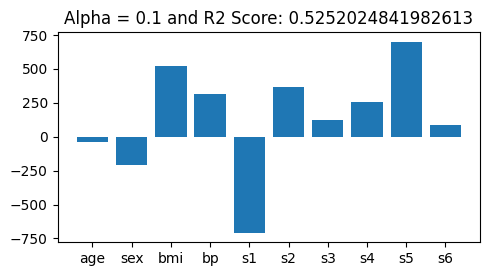

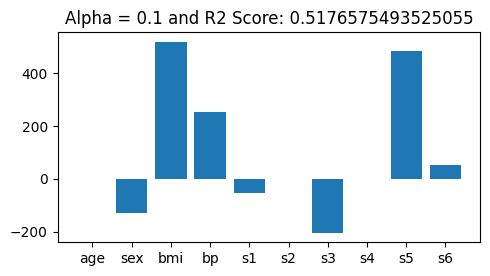

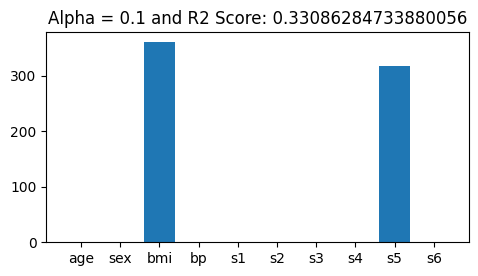

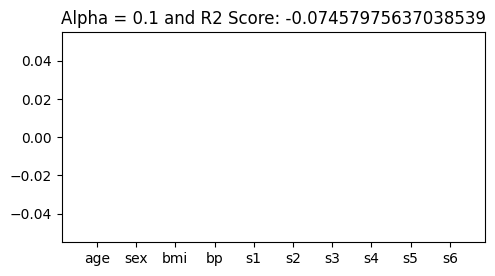

In [9]:
plt.figure(figsize=(12,6))
plt.subplot(221)
plt.bar(data.feature_names , coeff[0])
plt.title(f"Alpha = 0.1 and R2 Score: {r2Score[0]}")

plt.figure(figsize=(12,6))
plt.subplot(222)
plt.bar(data.feature_names , coeff[1])
plt.title(f"Alpha = 0.1 and R2 Score: {r2Score[1]}")

plt.figure(figsize=(12,6))
plt.subplot(223)
plt.bar(data.feature_names , coeff[2])
plt.title(f"Alpha = 0.1 and R2 Score: {r2Score[2]}")

plt.figure(figsize=(12,6))
plt.subplot(224)
plt.bar(data.feature_names , coeff[3])
plt.title(f"Alpha = 0.1 and R2 Score: {r2Score[3]}")

From the above we can conclude that the third graph has the feature selected columns and the 4th graph shows underfitting

### Impact of Bias and Varience in Lasso Regression

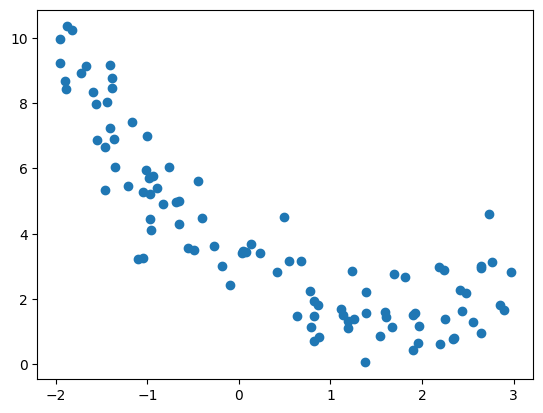

In [16]:
import numpy as np

m = 100
X = 5 * np.random.rand(m,1) - 2
y = 0.7 * X ** 2 - 2 * X + 3 + np.random.randn(m , 1)

plt.scatter(X,y)
plt.show()

In [31]:
X_train , X_test , y_train , y_test = train_test_split(X , y , random_state=44 , test_size=0.2)

In [32]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=10)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [33]:
X_train.reshape(-1 , 1)

array([[ 0.1272015 ],
       [-0.45249664],
       [-0.89647919],
       [-0.96561137],
       [ 2.55733637],
       [ 0.82278732],
       [-0.27451897],
       [ 0.63483911],
       [ 0.79207819],
       [ 2.64227789],
       [-1.67248613],
       [ 0.82399837],
       [ 2.33397394],
       [ 0.4192516 ],
       [-1.55414572],
       [ 1.3846378 ],
       [ 0.04136846],
       [ 2.73031043],
       [-0.82507387],
       [ 0.07915247],
       [ 1.19670135],
       [-1.0436559 ],
       [-0.65134043],
       [ 0.03668413],
       [-1.466859  ],
       [ 1.66694578],
       [ 1.95420367],
       [-0.40026961],
       [-0.98205305],
       [ 0.67339129],
       [ 1.59371792],
       [ 1.13883571],
       [-1.16925146],
       [-1.21093206],
       [ 1.69071765],
       [ 0.54380058],
       [-0.48719387],
       [ 1.11829635],
       [-0.55775586],
       [ 1.53859308],
       [-0.76415582],
       [ 2.24462412],
       [-1.95647035],
       [-1.41150104],
       [-0.94335285],
       [-1

In [37]:
from mlxtend.evaluate import bias_variance_decomp
from sklearn.linear_model import Lasso

alphas = np.linspace(0,30,100)

loss = []
bias = []
variance = []


for i in alphas:
    reg = Lasso(alpha=i)
    avg_expected_loss , avg_bias , avg_var = bias_variance_decomp(
    reg , X_train_poly , y_train , 
    X_test_poly , y_test , loss='mse', random_seed=123)
    loss.append(avg_expected_loss)
    bias.append(avg_bias)
    variance.append(avg_var)

c:\Users\biswa\Anaconda3PythonLatest2025\envs\venv\Lib\site-packages\sklearn\base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\biswa\Anaconda3PythonLatest2025\envs\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\biswa\Anaconda3PythonLatest2025\envs\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.056e+01, tolerance: 4.803e-02
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.l

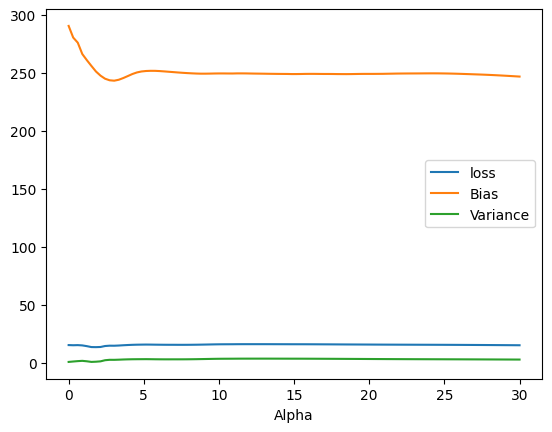

In [38]:
plt.plot(alphas,loss,label="loss")
plt.plot(alphas,bias,label="Bias")
plt.plot(alphas, variance, label="Variance")
plt.xlabel('Alpha')
plt.legend()